In [2]:
import os
import cv2
import json
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from utils.model2 import ObjectStateNet

## 0. utils

In [3]:
def load_model(backbone, attn, num_classes, checkpoint, device="cuda"):
    state_dict = torch.load(checkpoint, map_location=device)
    model = ObjectStateNet(
        backbone_name=backbone,
        num_classes=num_classes,
        pretrained=True,
        attn_type=attn,
        use_residual=True,
        fusion="object"
    )
    model.load_state_dict(state_dict)
    torch.set_grad_enabled(True) 
    model.to(device).eval()
    print(f"✅ Model loaded from {checkpoint}")
    return model

In [4]:
# checkpoint = "./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth"
# model = load_model(backbone="convnext_large", attn="bicross", num_classes=3, checkpoint = checkpoint, device="cuda")
# model.object_extractor.features[0][7][-1]

In [5]:
def get_data(ann_file, label2id, img_path_root):
    data = []
    with open(ann_file, "r") as fp:
        raw_data = json.loads(fp.read())
    
    for k, v in raw_data.items():
        img_name = f"{k}.jpg"
        img_path = os.path.join(img_path_root, img_name)
    
        for i, ann in v.items():
            x1,y1,x2,y2 = ann["bbox"] #xyxy
            w = x2 - x1
            h = y2 - y1
            label = ann["label"]
            if label == "Unrelated Region":
                continue
    
            data.append({
                "img_path": img_path,
                "bbox": [x1, y1, w, h],
                "label": label2id[label]
            })
            
    return data

In [6]:
def img_preprocess(item):
    img_path = item["img_path"]
    bbox = item["bbox"]
    label = item["label"]
    
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    original_img = Image.open(img_path).convert("RGB")
    img_W, img_H = original_img.size
    x1, y1, w, h = bbox
    x2 = x1 + w
    y2 = y1 + h
    cropped_region = original_img.crop((x1, y1, x2, y2))

    image = test_transform(original_img)
    cropped_region = test_transform(cropped_region)

    bbox_normed = torch.tensor([
        x1 / img_W,
        y1 / img_H,
        x2 / img_W,
        y2 / img_H
    ], dtype=torch.float32)

    return {
        "original": image.unsqueeze(0).cuda(),
        "crop": cropped_region.unsqueeze(0).cuda(),
        "bbox": bbox_normed.unsqueeze(0).cuda(),
        "label": label
    }

In [7]:
def get_vit_target_layer(model, extractor_name, layer=-2):
    extractor = getattr(model, extractor_name)
    assert layer in [-1,-2,-3,-4,-5, -6]
    return extractor.features.encoder.layers[layer]

def get_convnext_target_layer(model, extractor_name, layer=-1):
    extractor = getattr(model, extractor_name)
    return extractor.features[0][7][layer]

def vit_reshape_transform(tensor, height=14, width=14):
    result = tensor[:,1:,:]
    result = result.reshape(result.size(0), height, width, result.size(-1))
    # convert to [B, C, H, W] for Grad-CAM
    result = result.permute(0, 3, 1, 2)
    return result

# Step 1: 设置 reshape_transform
def vit_reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :]  # 去除 CLS token
    result = result.reshape(result.size(0), height, width, result.size(-1))
    result = result.permute(0, 3, 1, 2)  # [B, C, H, W]
    return result

In [8]:
class CAMWrapper(nn.Module):
    def __init__(self, model, img_global, img_object, bbox, branch):
        super().__init__()
        self.model = model
        self.img_global = img_global
        self.img_object = img_object
        self.bbox = bbox
        self.branch = branch

    def forward(self, x):
        if self.branch == "object":
            return self.model(
                img_global=self.img_global,
                img_object=x,
                bbox=self.bbox
            )
        elif self.branch == "global":
            return self.model(
                img_global=x,
                img_object=self.img_object,
                bbox=self.bbox
            )
        else:
            raise ValueError("Unsupported branch")

In [9]:
# for name, param in model.named_parameters():
#     if param.requires_grad and param.grad is not None:
#         print("✅ 有梯度：", name, param.grad.norm())

In [10]:
def run_gradcam(backbone, model, item, branch = "object", layer=-1, use_plusplus = True, save_path = None ):
    # # 1. 获取model
    # model = load_model(
    #     backbone = backbone,
    #     attn = attn,
    #     num_classes = num_classes,
    #     checkpoint = checkpoint
    # )
    model.eval() # 模型设置测试模式
    model.zero_grad() # 清空模型的梯度
    
    # 2. 获取数据
    inputs = img_preprocess(item)
    img_global = inputs["original"]   # 整张图 (global image) : Tensor[B,3,224,224]
    img_object = inputs["crop"]       # 裁剪区域 (cropped object image)
    bbox = inputs["bbox"]             # 归一化目标框 [x1,y1,x2,y2]
    label = inputs["label"] # ==> 这里的类型就是int

    # 3. 选择目标层【决定在哪个特征层上计算梯度】
    wrapped_model = CAMWrapper(
        model = model, 
        img_global = img_global, 
        img_object = img_object, 
        bbox = bbox, 
        branch = branch
    )

    # 4. 获取target layer
    if branch == "object":
        extractor_name = "object_extractor"
        input_tensor = img_object.requires_grad_()
        # 生成用于叠加的原图(a. global叠加原图)
        x1, y1, w, h = item["bbox"]
        rgb = np.float32(Image.open(item["img_path"]).convert("RGB").crop((x1, y1, x1+w, y1+h)).resize((224, 224))) / 255
    elif branch == "global":
        extractor_name = "global_extractor"
        input_tensor = img_global.requires_grad_()
        # 生成用于叠加的原图(b. object叠加原图)
        rgb = np.float32(Image.open(item["img_path"]).convert("RGB").resize((224, 224))) / 255
    
    if backbone == "vit_b_16":
        target_layer = get_vit_target_layer(model, extractor_name = extractor_name, layer=layer)
    elif backbone == "convnext_large":
        target_layer = get_convnext_target_layer(model, extractor_name = extractor_name, layer=layer)

    # 5. GradCAM 实例化
    cam_class = GradCAMPlusPlus if use_plusplus else GradCAM
    

    # 6. 选择目标类别
    targets = [ClassifierOutputTarget(label)]

    # 7. 获取 cam mask

    with cam_class(
        model=wrapped_model,
        target_layers=[target_layer],
        use_cuda=torch.cuda.is_available(),
        reshape_transform=vit_reshape_transform if backbone == "vit_b_16" else None
    ) as cam:
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

    # 8. 展示图片
    def visualize_cam_on_image(rgb_np, grayscale_cam, save_path, alpha=0.3):
        # cam_image = show_cam_on_image(rgb_np, grayscale_cam[0], use_rgb=True, alpha=0.3)
        cam_image = show_cam_with_alpha(rgb_np, grayscale_cam[0], alpha=0.3)
        return cam_image
        # plt.figure(figsize=(6, 6))
        # plt.imshow(cam_image)
        # plt.axis('off')
        # plt.tight_layout()
        # plt.show()

        # if save_path is not None:
        #     Image.fromarray(cam_image).save(save_path)
        #     print(f"✅ 已保存 Grad-CAM 图像到: {save_path}")
        # else:
        #     print("✅ Grad-CAM 不保存")

    
    
    cam_image = visualize_cam_on_image(rgb, grayscale_cam, save_path=save_path)
    del cam
    del wrapped_model
    del model
    del input_tensor
    del grayscale_cam
    torch.cuda.empty_cache()
    return rgb, cam_image

In [11]:
def show_cam_with_alpha(rgb_np, grayscale_cam, alpha=0.3):
    """
    手动融合 grayscale_cam 和 rgb_np，控制 alpha 透明度
    :param rgb_np: 原图（归一化后的 float32 格式，范围 [0, 1]）
    :param grayscale_cam: Grad-CAM 的输出，单通道 [H, W]，范围 [0, 1]
    :param alpha: 热力图的透明度（0=全原图，1=全热图）
    :return: 融合后的图像（RGB, uint8）
    """

    # 确保热力图值在 [0, 1]
    grayscale_cam = np.clip(grayscale_cam, 0, 1)

    # 应用 colormap
    colormap = cm.get_cmap("jet")
    heatmap = colormap(grayscale_cam)[:, :, :3]  # 去掉 alpha 通道

    # 融合（必须先转换为 float32）
    heatmap = np.float32(heatmap)
    rgb_np = np.float32(rgb_np)
    cam_image = (1 - alpha) * rgb_np + alpha * heatmap

    # 转成 uint8
    cam_image = np.uint8(255 * cam_image)
    return cam_image

## 1. 加载数据

In [385]:
datasets = [
    "1. gas cylinder",
    "2. working at height",
    "3. worker with hardhat & vest",
    "4. working with eye protection",
    "5. vehicle"
]
ds_id = 1
dataset = datasets[ds_id]
test_img_path = f"./config_file/{dataset}/testImgs/"
test_ann_file = f"./config_file/{dataset}/testImgs/bboxes_{ds_id + 1}.json"
labels_file = f"./config_file/{dataset}/testImgs/labels_{ds_id + 1}.json"

with open(labels_file, "r") as fp:
    label2id = json.loads(fp.read())
num_classes = len(label2id)

data = get_data(ann_file=test_ann_file, label2id=label2id, img_path_root=test_img_path)

In [386]:
def get_data_wrapper(ds_id):
    datasets = [
        "1. gas cylinder",
        "2. working at height",
        "3. worker with hardhat & vest",
        "4. working with eye protection",
        "5. vehicle"
    ]
    dataset = datasets[ds_id]
    test_img_path = f"./config_file/{dataset}/testImgs/"
    test_ann_file = f"./config_file/{dataset}/testImgs/bboxes_{ds_id + 1}.json"
    labels_file = f"./config_file/{dataset}/testImgs/labels_{ds_id + 1}.json"
    
    with open(labels_file, "r") as fp:
        label2id = json.loads(fp.read())
    num_classes = len(label2id)
    
    data = get_data(ann_file=test_ann_file, label2id=label2id, img_path_root=test_img_path)
    return data, num_classes

## 2. Grad-CAM

In [14]:
def save_imgs(img1, img2, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4)) 
    axes[0].imshow(img1)
    axes[0].axis("off")
    axes[1].imshow(img2)
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

def resize_img(img_np, w, h):

    if img_np.dtype != np.uint8:
        img_np = (img_np * 255).clip(0, 255).astype(np.uint8)
        
    img = Image.fromarray(img_np)
    img_resize = img.resize((w, h), Image.BILINEAR)
    return img_resize

In [13]:
backbones = ["convnext_large", ]#"vit_b_16"

checkpoints = {
    "vit_b_16":[
        "./config_file/explanable_results/models/0_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_vit_b_16_bicross_model_bbtrainable.pth",
    ],
    "convnext_large":[
        "./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_convnext_large_bicross_model_bbtrainable.pth",
    ]
}

for backbone in backbones:
    for ds_id in range(2, 5):
        checkpoint = checkpoints[backbone][ds_id]
        data, num_classes = get_data_wrapper(ds_id=ds_id)
        model = load_model(
            backbone = backbone,
            attn = "bicross",
            num_classes = num_classes,
            checkpoint = checkpoint
        )
        folder_path = f"./explainable imgs/{backbone}/{ds_id}/"
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)

        print(f"---processing--> {backbone} - {ds_id}")
        
        for i, d in enumerate(data):
            rgb_g, cam_image_g = run_gradcam(
                backbone = backbone, 
                model = model,
                item = d, 
                branch = "global", # object / global
                layer= -2 if backbone == "vit_b_16" else -1, 
                use_plusplus = True, 
                save_path = None 
            )

            

            rgb_o, cam_image_o = run_gradcam(
                backbone = backbone, 
                model = model,
                item = d, 
                branch = "object", # object / global
                layer= -2 if backbone == "vit_b_16" else -1, 
                use_plusplus = True, 
                save_path = None 
            )

            origin_img = Image.open(d["img_path"])
            w, h = origin_img.size
            rgb_resize_g = resize_img(rgb_g, w, h)
            cam_image_resize_g = resize_img(cam_image_g, w, h)
            

            bbox = d["bbox"]
            _, _, w, h = bbox
            rgb_resize_o = resize_img(rgb_o, w, h)
            cam_image_resize_o = resize_img(cam_image_o, w, h)

            
            img_id = d["img_path"].split("/")[-1].split(".")[0]
            label = d["label"]
            object_path = folder_path + f"{label}_{img_id}_{i}_object.jpg"
            global_path = folder_path + f"{label}_{img_id}_{i}_global.jpg"
            save_imgs(rgb_resize_o, cam_image_resize_o, object_path)
            save_imgs(rgb_resize_g, cam_image_resize_g, global_path)

✅ Model loaded from ./config_file/explanable_results/models/2_convnext_large_bicross_model_bbtrainable.pth
---processing--> convnext_large - 2
✅ Model loaded from ./config_file/explanable_results/models/3_convnext_large_bicross_model_bbtrainable.pth
---processing--> convnext_large - 3
✅ Model loaded from ./config_file/explanable_results/models/4_convnext_large_bicross_model_bbtrainable.pth
---processing--> convnext_large - 4


In [387]:
bb_id = 0
# ds_id = 4
backbones = ["vit_b_16", "convnext_large", ]

checkpoints = {
    "vit_b_16":[
        "./config_file/explanable_results/models/0_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_vit_b_16_bicross_model_bbtrainable.pth",
    ],
    "convnext_large":[
        "./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_convnext_large_bicross_model_bbtrainable.pth",
    ]
}

checkpoint = checkpoints[backbones[bb_id]][ds_id]

In [388]:
model = load_model(
    backbone = backbones[bb_id],
    attn = "bicross",
    num_classes = num_classes,
    checkpoint = checkpoint
)

✅ Model loaded from ./config_file/explanable_results/models/1_vit_b_16_bicross_model_bbtrainable.pth


In [19]:
for i, d in enumerate(data):
    if d["label"] == 3:
        print(i)

5
12
59
78
80
81
84
89
122
172
173
174
175
177
179
180
182
183
184
185
187
188
189
190
191
192
193
194
196
197
198
200
201
202
203
204
205
206
208
209
210
211
212
214
215
217
219
221
222
225


In [411]:
item_id = 30
# checkpoint = "./config_file/explanable_results/models/0_vit_b_16_bicross_model_bbtrainable.pth"
# checkpoint = "./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth


rgb, cam_image = run_gradcam(
    backbone = backbones[bb_id], 
    # attn = "bicross", 
    # num_classes = num_classes, 
    # checkpoint = checkpoint, 
    model = model,
    item = data[item_id], 
    branch = "object", # object / global
    layer=-6, 
    use_plusplus = True, 
    save_path = None 
)

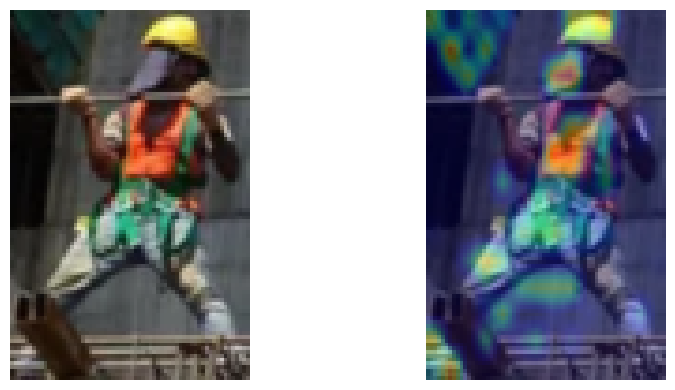

In [412]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1行2列

bbox = data[item_id]["bbox"]
w = bbox[2]
h = bbox[3]

# 左图
rgb_resize = resize_img(rgb, w, h)
axes[0].imshow(rgb_resize)
# axes[0].set_title("Image 1")
axes[0].axis("off")

# 右图
cam_image_resize = resize_img(cam_image, w, h)
axes[1].imshow(cam_image_resize)
# axes[1].set_title("Image 2")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("./4_4_1_68_113_object_vit",dpi=300, bbox_inches='tight')
plt.show()

In [367]:
data[item_id]

{'img_path': './config_file/4. working with eye protection/testImgs/4_1_106.jpg',
 'bbox': [335, 0, 189, 252],
 'label': 4}

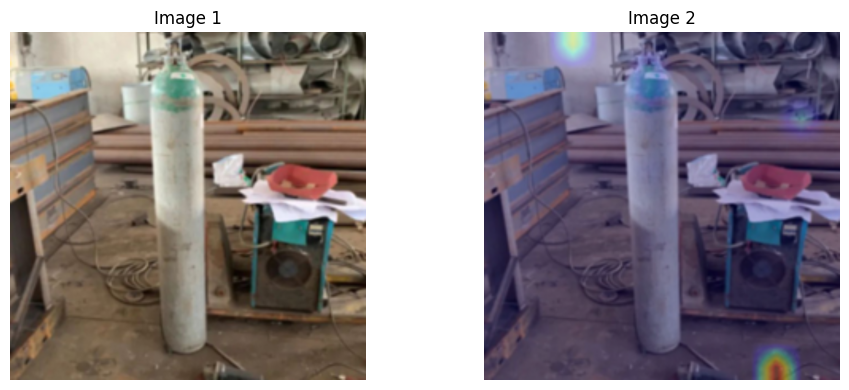

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1行2列

origin_img = Image.open(data[item_id]["img_path"])
w, h = origin_img.size

# 左图
rgb_resize = resize_img(rgb, w, h)
axes[0].imshow(rgb_resize)
axes[0].set_title("Image 1")
axes[0].axis("off")

# 右图
cam_image_resize = resize_img(cam_image, w, h)
axes[1].imshow(cam_image_resize)
axes[1].set_title("Image 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 测试代码

In [31]:
# model.object_extractor.features[0][7][-1]

In [32]:
# checkpoint = "./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth"
# bb_id = 0
# backbones = ["convnext_large", "vit_b_16"]
# attn_type = "bicross"

# item_id = 0
# item = data[item_id]

# model = load_model(
#     backbone = backbones[bb_id], 
#     attn=attn_type, 
#     num_classes=num_classes, 
#     checkpoint = checkpoint
# )


# model.eval()
# model.zero_grad()

# inputs = img_preprocess(item)
# img_global = inputs["original"]   # 整张图 (global image) : Tensor[B,3,224,224]
# img_object = inputs["crop"]       # 裁剪区域 (cropped object image)
# bbox = inputs["bbox"]             # 归一化目标框 [x1,y1,x2,y2]
# label = inputs["label"] # ==> 这里的类型就是int

# x1, y1, w, h = item["bbox"]
# rgb = np.float32(
#     Image.open(item["img_path"]).convert("RGB").crop((x1, y1, x1+w, y1+h)).resize((224, 224))
# ) / 255.0

# branch = "object"
# wrapped = CAMWrapper(
#     model = model, 
#     img_global = inputs["original"], 
#     img_object = inputs["crop"], 
#     bbox = inputs["bbox"], 
#     branch = branch
# )

# # def _probe(module, input, output):
# #     print("🧩 output from target_layer:", output.shape)
# #     output.retain_grad()

# # hook = target_layer.register_forward_hook(_probe)
# # model(img_global=img_global, img_object=img_object, bbox=bbox)
# # hook.remove()

# target_layer = get_convnext_target_layer(model, "object_extractor",layer=-3)
# if branch == "object":
#     input_tensor = img_object.requires_grad_()
# elif branch == "global":
#     input_tensor = img_global.requires_grad_()

# # Step 2: GradCAM 实例化
# cam = GradCAMPlusPlus(
#     model=wrapped,
#     target_layers=[target_layer],
#     use_cuda=torch.cuda.is_available(),
#     # reshape_transform=vit_reshape_transform
# )

# # # Step 3: 选择目标类别
# targets = [ClassifierOutputTarget(label)]

# # # # Step 4: 获取 cam mask
# grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

# np.unique(grayscale_cam)

# # ========= 3. 可视化函数 ==========
# def visualize_cam_on_image(rgb_np, grayscale_cam):
#     cam_image = show_cam_on_image(rgb_np, grayscale_cam[0], use_rgb=True)
    
#     plt.figure(figsize=(6, 6))
#     plt.imshow(cam_image)
#     plt.title("Grad-CAM")
#     plt.axis('off')
#     plt.tight_layout()
#     plt.show()

# visualize_cam_on_image(rgb, grayscale_cam)